# 获取所有选手的最高的ELO值

In [22]:
import pandas as pd
import itertools
file_path=r"C:\Users\Administrator\Desktop\playerstyles\namemaps\downloads\all.csv"
df=pd.read_csv(file_path)
df['Name']=df['Name'].fillna(df['Username'])

In [24]:
name_to_elos=df.groupby('Name')['Rating'].max().to_dict()
name_elo_mapping_df=pd.DataFrame.from_dict(name_to_elos,orient='index')
print("行索引：", name_elo_mapping_df.index.tolist()[:5])
print("数据列名：", name_elo_mapping_df.columns.tolist())

行索引： ['107degrees', '162a54f5d', '190l', '1b31-O', '1d51-0']
数据列名： [0]


In [25]:
name_elo_mapping_df.rename(columns={0:'ELO'},inplace=True)
print("修改后的数据列名：", name_elo_mapping_df.columns.tolist())
name_elo_mapping_df.reset_index(inplace=True)
name_elo_mapping_df.rename(columns={"index": "Name"}, inplace=True)
print("最终列名：", name_elo_mapping_df.columns.tolist())
print("\n表格前5行：")
print(name_elo_mapping_df.head())

修改后的数据列名： ['ELO']
最终列名： ['Name', 'ELO']

表格前5行：
         Name     ELO
0  107degrees  2366.0
1   162a54f5d   800.0
2        190l  2233.0
3      1b31-O  2450.0
4      1d51-0  2199.0


In [26]:
name_elo_mapping_df.to_csv('name_to_elos.csv')

# 所有选手的最新ELO分布状况

In [1]:
import pandas as pd
import numpy as np
import itertools
df=pd.read_csv(r"C:\Users\Administrator\Desktop\Chess\basic\newestELO\name_to_elos.csv")

In [2]:
df.head()

,Unnamed: 0,Name,ELO
0,0,107degrees,2366.0
1,1,162a54f5d,800.0
2,2,190l,2233.0
3,3,1b31-O,2450.0
4,4,1d51-0,2199.0


In [3]:
elo_stats = df['ELO'].describe()
print(elo_stats)

count    9606.000000
mean     2492.946908
std       291.854408
min       353.000000
25%      2338.000000
50%      2514.000000
75%      2675.000000
max      3319.000000
Name: ELO, dtype: float64


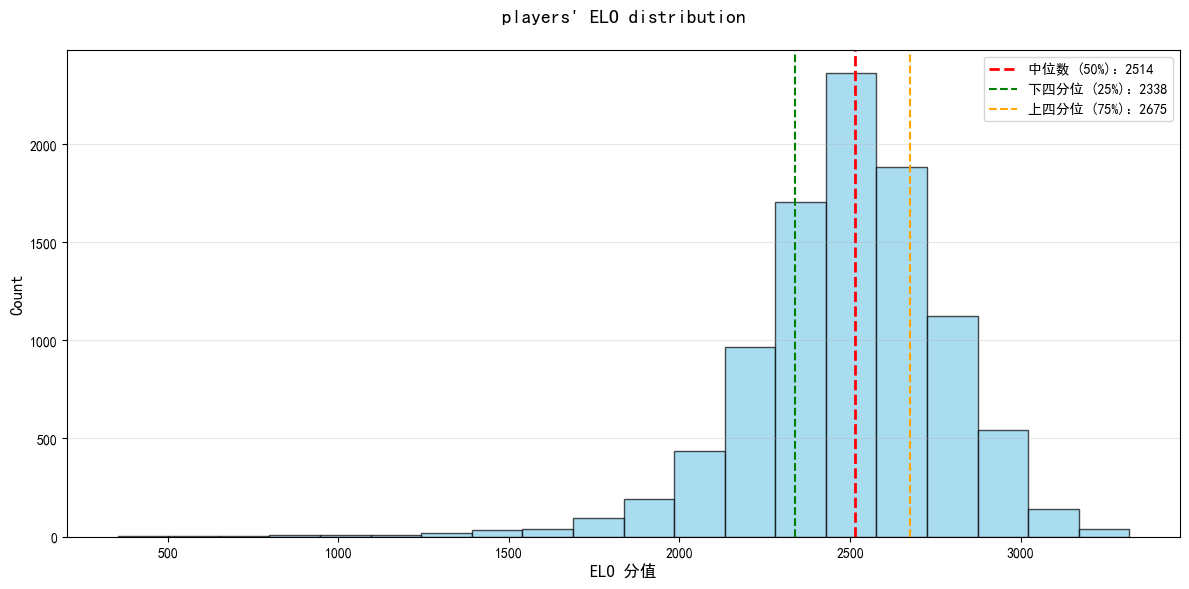

下四分位数（25%）：2338
中位数（50%）：2514
上四分位数（75%）：2675


In [ ]:
plt.rcParams['font.sans-serif'] = ['SimHei']   
plt.rcParams['axes.unicode_minus'] = False    
plt.figure(figsize=(12, 6))  

q25 = df['ELO'].quantile(0.25)   # 下四分位数（25%）
q50 = df['ELO'].quantile(0.5)    # 中位数（50%）
q75 = df['ELO'].quantile(0.75)   # 上四分位数（75%）

n, bins, patches = plt.hist(
    df['ELO'], 
    bins=20,         
    color='skyblue',  
    edgecolor='black',
    alpha=0.7         
)

plt.axvline(q50, color='red', linestyle='--', linewidth=2, label=f'中位数 (50%)：{q50:.0f}')
plt.axvline(q25, color='green', linestyle='--', linewidth=1.5, label=f'下四分位 (25%)：{q25:.0f}')
plt.axvline(q75, color='orange', linestyle='--', linewidth=1.5, label=f'上四分位 (75%)：{q75:.0f}')

plt.xlabel('ELO 分值', fontsize=12)          # 横坐标标签
plt.ylabel('Count', fontsize=12)          # 纵坐标标签
plt.title("players' ELO distribution", fontsize=14, pad=20)  # 标题
plt.legend(loc='upper right')                # 图例位置
plt.grid(axis='y', alpha=0.3)                # 仅显示纵向网格线，更清晰

plt.tight_layout() 
plt.savefig(r"C:\Users\Administrator\Desktop\Chess\ELO\elo_bar_dist.png", dpi=300)
plt.show()

print(f"下四分位数（25%）：{q25:.0f}")
print(f"中位数（50%）：{q50:.0f}")
print(f"上四分位数（75%）：{q75:.0f}")

In [8]:
top5 = df.sort_values('ELO', ascending=False).head(5)
# 按ELO升序排序，取前6（最低）
bottom6 = df.sort_values('ELO', ascending=True).head(6)

# ---------------------- 3. 筛选中间5人（按ELO排序后取中位数附近的5条） ----------------------
# 先按ELO升序排序
df_sorted = df.sort_values('ELO', ascending=True).reset_index(drop=True)
# 计算中间位置的起始索引
total_count = len(df_sorted)
middle_start = (total_count // 2) - 2  # 中间5人的起始位置（比如总数为N，取 N/2-2 到 N/2+2）
# 确保起始索引不小于0，结束索引不超过总数
middle_start = max(0, middle_start)
middle_end = middle_start + 5
middle5 = df_sorted.iloc[middle_start:middle_end]

# ---------------------- 4. 格式化打印结果 ----------------------
print("="*50)
print("ELO分值最高的5位选手：")
print("-"*30)
for idx, row in top5.iterrows():
    print(f"{idx+1}. {row['Name']} - ELO: {row['ELO']:.0f}")

print("\n" + "="*50)
print("ELO分值最低的6位选手：")
print("-"*30)
for idx, row in bottom6.iterrows():
    print(f"{idx+1}. {row['Name']} - ELO: {row['ELO']:.0f}")

print("\n" + "="*50)
print("ELO分值处于中间位置的5位选手：")
print("-"*30)
for idx, row in middle5.iterrows():
    print(f"{idx+1}. {row['Name']} - ELO: {row['ELO']:.0f}")

ELO分值最高的5位选手：
------------------------------
3448. Hikaru Nakamura - ELO: 3319
5123. Magnus Carlsen - ELO: 3309
6165. Nihal Sarin - ELO: 3280
6505. Parham Maghsoodloo - ELO: 3272
9089. dogsofwar - ELO: 3266

ELO分值最低的6位选手：
------------------------------
4176. Jorge Lopez Valdez - ELO: 353
9033. beza mek - ELO: 383
8816. Yazid Touil King - ELO: 442
7101. Roberto Carlos Salazar Parejo - ELO: 446
9213. lucien benyaich - ELO: 573
3426. Henry Perdomo - ELO: 627

ELO分值处于中间位置的5位选手：
------------------------------
4803. Karl Bowden - ELO: 2514
4804. Dmitry Bagrationi - ELO: 2514
4805. Hairan Liang - ELO: 2514
4806. Soltan Muradov - ELO: 2514
4807. Dharim Bacus - ELO: 2514
